In [1]:
from collections import defaultdict
# from matplotlib import pyplot as plt
from munkres import Munkres
import numpy as np
from statistics import mode
import random
import time
# from tqdm import tqdm,trange

# plt.rcParams.update({'font.size': 18})
# %matplotlib inline

import tkinter as tk
import random



from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import matplotlib.pyplot as plt


In [2]:
''' blocks_pos = [K,2]
    occupied: set of positions'''
def initialize_blocks(K,L):
    blocks_pos =[]
    occupied = set()
    while len(occupied)<K:
        (x,y) = np.random.choice(range(L), 2)
        if (x,y) not in occupied:
            blocks_pos.append((x,y))
            occupied.add((x,y))
    blocks_pos = np.array(blocks_pos)
    return blocks_pos, occupied


'''return the matrix of all possible distances between blocks'''
def dist_matrix(p1,p2):
    return np.sqrt(((p1[:,None] - p2[None,:])**2).sum(-1))


''' return the min distance between configs and the list of optimal swap'''
def dist_moves(blocks_pos,g1):
    matrix = dist_matrix(blocks_pos, g1)
    m = Munkres()
    best_idxs = m.compute(np.copy(matrix))
    dist =0 
    for (k, l) in best_idxs:
        dist+= (matrix[k][l])
    return dist,best_idxs



def simulate_move(blocks_pos, g1):
    d = dist_moves(blocks_pos, g1)[0]
    done = False
    
    while not done:
        blocks_pos_new = np.copy(blocks_pos)

        sel = np.random.choice(range(K))
        (x,y) = blocks_pos[sel]     ## choose a random block

        poss_moves =[]
        for x1,y1 in [(x+1,y),(x-1,y),(x,y+1),(x,y-1)]:
            if tuple((x1,y1)) not in set(tuple(blocks_pos[i]) for i in range(K)) and 0<=x1<L and 0<=y1<L:
                poss_moves.append((x1,y1))

        if len(poss_moves)==0: continue

        x1,y1 = poss_moves[np.random.choice(len(poss_moves))] ## choose one of the possible moves

        blocks_pos_new[sel] = (x1,y1)
        d_new = dist_moves(blocks_pos_new, g1)[0]

        if np.log(np.random.uniform(0,1)) < - beta * (d_new - d): 
            return blocks_pos_new



'''prob of observing that move
- if g is correct, and a=guess, then o1=g
- if g is correct, and a=wait, then it just gets close

--> separate the two actions
- a=wait: update with bayes
- a=guess:
'''
def get_move_prob(config, new_config, g, a, guess=0):
    if a=='guess' and np.all(g ==G[guess]):
        if np.all(new_config==g): p=1000
        else: p=0 
    else:
        d = dist_moves(config, g)[0]
        d1 = dist_moves(new_config, g)[0]
        p = np.exp(-beta*(d1-d))    
    return p




def particle_filter(particles, blocks_pos_new,a, phi):
    ## compute prob of observing that move given the goal in each particle
    prob_p = np.zeros(N)
    goal_indices = [p.goal_index for p in particles]
    guess = mode(goal_indices)
    ## ------------------------- loop over the particles ---- TODO run in parallel
    for p in range(N):
        g_p = particles[p].goal_index
        config_p = particles[p].blocks_pos
        prob_p[p] = get_move_prob(config_p, blocks_pos_new, G[g_p], a ,guess)
        # print(prob_p)

    if prob_p.sum() == 0:
        prob_p[:] = 1/N
    else:
        prob_p /= prob_p.sum()
    ## --------------------------


    # resample particle indices based on these probabilities

    
    indices = np.random.choice(goal_indices, p=prob_p, size=N)
    indices[:int(N*phi)] = np.random.choice(range(M), size=int(N*phi))


    
    # create new list of resampled particles with updated config (after move)
    new_particles = []
    for i in range(N):
        new_particles.append(Particle(indices[i], blocks_pos_new))  # blocks_pos_new = observed new state
    

    print('updated')
    return new_particles





## -------------------------------------------------------------------
class TreeNode:
    def __init__(self, history):
        self.history = history  # list of (action, obs) 
        self.children = {}      # dict: key=(action, obs), value=TreeNode
        self.N = {}  # number of visits per action (per action dict)
        self.Q = {}  # vestimated value per action


    def get_child(self, blocks_pos, action):
        obs_key = tuple(sorted(map(tuple, blocks_pos)))
        key = (action, obs_key)
        if key not in self.children:
            new_history = self.history + [key]
            self.children[key] = TreeNode(new_history)
        return self.children[key]


    def __repr__(self):
        return f"TreeNode(history={self.history}, N={dict(self.N)}, Q={dict(self.Q)})"


class Particle:
    def __init__(self, goal_index, blocks_pos):
        self.goal_index = goal_index
        self.blocks_pos = np.copy(blocks_pos)


def UCB_sel(blocks_pos, node):
    best_value, best_action = -np.inf, None
    for a in actions:
        obs_key = tuple(sorted(map(tuple, blocks_pos)))
        key = (a, obs_key)
        if key not in node.children:
            ucb_value = np.inf
        else:
            child = node.children[key]
            q_value = child.Q.get(a, 0.0)
            n_value = child.N.get(a, 0)
            ucb_value = q_value + c * np.sqrt(np.log(sum(node.N.values()) + 1) / (n_value + 1e-6))
        if ucb_value > best_value:
            best_value, best_action = ucb_value, a

    return best_action

    # print(f"Action: {action}, Q: {child.Q if key in node.children else 'N/A'}, N: {child.N if key in node.children else 'N/A'}, UCB: {ucb_value}")


    return action


def rollout(blocks_pos, particle_goal, depth, max_depth):
    if depth>max_depth: return 0
    actions = ["wait", "guess"]
    action = np.random.choice(actions)

    if action == "wait":
        new_blocks_pos = simulate_move(blocks_pos, particle_goal)
        reward = 0  
        return reward + gamma* rollout(new_blocks_pos, particle_goal, depth+1, max_depth)

    elif action == "guess":
        return Rmax
    

## note:use only the particle's goal!
def simulate(particle, node, depth, max_depth):
    goal_index, blocks_pos = particle.goal_index, particle.blocks_pos

    if depth >= max_depth:
        return rollout(blocks_pos, G[goal_index], depth, max_depth)

    if len(node.children) == 0:
        action = np.random.choice(actions)
    else:
        action = UCB_sel(blocks_pos, node)

    if action == "wait":
        new_blocks_pos = simulate_move(blocks_pos, G[goal_index])
        reward = 0
        child_node = node.get_child(new_blocks_pos, action)
        new_particle = Particle(goal_index, new_blocks_pos)
        total_reward = reward + gamma * simulate(new_particle, child_node, depth+1, max_depth)

    elif action == "guess":
        new_blocks_pos = G[goal_index]
        child_node = node.get_child(new_blocks_pos, action)
        total_reward = Rmax

    node.N[action] = node.N.get(action, 0) + 1
    node.Q[action] = ((node.N[action] - 1) * node.Q.get(action, 0.0) + total_reward) / node.N[action]

    return total_reward


def select_action(root, particles, n_simulations=200):
    for _ in range(n_simulations):
        particle = random.choice(particles)
        simulate(particle, root, 0, max_depth)
    best_action = max(root.Q, key=root.Q.get)
    return best_action


### ___________________________________________________________________
### Define goal patterns
# g1 = np.array(((2,3),(3,3),(2,4),(3,4),(2,5),(3,5)))
# g2 = np.array(((0,3),(1,3),(2,3),(3,3),(4,3),(5,3)))
# g3 = np.array(((0,3),(0,4),(0,5),(1,4),(1,5),(2,5)))
# g4 = np.array(((1,0),(2,0),(3,0),(2,1),(2,2),(2,3)))
# g5 = np.array(((3,0),(4,0),(5,0),(3,1),(4,1),(5,1)))
# g6 = np.array(((0,3),(1,3),(0,4),(1,4),(0,5),(1,5)))
# g7 = np.array(((0,0),(1,0),(2,0),(3,0),(4,0),(5,0)))
# g8 = np.array(((0,0),(1,0),(0,1),(1,1),(0,2),(1,2)))
# g9 = np.array(((2,0),(3,0),(2,1),(3,1),(2,2),(3,2)))
# g10 = np.array(((4,0),(5,0),(4,1),(5,1),(4,2),(5,2)))
# g11 = np.array(((4,3),(5,3),(4,4),(5,4),(4,5),(5,5)))
# g12 = np.array(((1,5),(2,5),(3,5),(4,5),(2,4),(3,4)))
# g13 = np.array(((1,0),(2,0),(3,0),(4,0),(2,1),(3,1)))
# g14 = np.array(((0,0),(0,1),(0,2),(1,0),(2,0),(3,0)))
# g15 = np.array(((0,2),(0,3),(0,4),(0,5),(1,5),(2,5)))


### -----------------------------------------------------------
# Goal Patterns - 05252025 - 4 Blocks 15 x 15 Grid
g1 = np.array([(0, 0), (0, 1), (0, 2), (0, 3)])  # horizontal line
g2 = np.array([(1, 0), (2, 0), (3, 0), (4, 0)])  # vertical line
g3 = np.array([(5, 5), (5, 6), (6, 5), (6, 6)])  # 2x2 square
g4 = np.array([(7, 7), (7, 8), (7, 9), (8, 9)])  # L-shape
g5 = np.array([(9, 9), (10, 9), (10, 10), (10, 11)])  # reverse L-shape
g6 = np.array([(2, 2), (3, 2), (3, 3), (4, 3)])  # diagonal L
g7 = np.array([(0, 10), (1, 10), (1, 11), (2, 11)])  # step pattern
g8 = np.array([(10, 0), (10, 1), (11, 1), (12, 1)])  # another L
g9 = np.array([(6, 10), (7, 10), (8, 10), (8, 11)])  # L-right
g10 = np.array([(5, 2), (6, 2), (6, 3), (7, 3)])  # staggered down-right
g11 = np.array([(8, 5), (8, 6), (9, 6), (9, 7)])  # staggered right-down
g12 = np.array([(12, 12), (12, 13), (13, 12), (13, 13)])  # bottom-right square
g13 = np.array([(0, 14), (1, 14), (1, 13), (2, 13)])  # upper-right L
g14 = np.array([(14, 0), (14, 1), (13, 1), (13, 2)])  # bottom-left L
g15 = np.array([(4, 6), (5, 6), (6, 6), (6, 7)])  # vertical with right tip

G_all = [g1,g2,g3,g4,g5,g6,g7,g8,g9,g10,g11,g12,g13,g14,g15]

In [3]:
def plot_possible_patterns():
    L = 15
    cols = 5
    rows = int(np.ceil(len(G_all) / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))

    for i, (g, ax) in enumerate(zip(G_all, axes.flat)):
        ax.set_xlim(-0.5, L-0.5)
        ax.set_ylim(-0.5, L-0.5)
        ax.set_xticks(range(L))
        ax.set_yticks(range(L))
        # ax.grid(True)

        # Draw occupied cells
        for (x, y) in g:
            ax.add_patch(plt.Rectangle((x-0.5, y-0.5), 1, 1, color="black"))

        ax.set_title(f"G{i+1}")
        ax.invert_yaxis()

    # Hide any extra subplots
    for j in range(len(G_all), len(axes.flat)):
        axes.flat[j].axis('off')

    plt.tight_layout()


# START here!

In [45]:
## --------- PARAMETERS -------------------

M = 15 #number of possible patterns
# M = 3 #number of possible patterns
K = 4 #number of blocks
L = 15 #size of grid
N = 1000 #number of particles

G = G_all[:M]

beta = 1 #parameter in P(s) ~ exp(-b d(s,g))
gamma = 0.9 ## discount factor
c = 1.5 ## factor in UCB weight
max_depth = 10
Rmax = 10

actions = ["wait", "guess"]

#-------------
cell_size = 50
max_moves = 2


phi = 0.2 # fraction of randomly reassigned particles

In [46]:
import tkinter as tk

def ask(obs, current):
    result = {"value": None}

    def on_yes():
        result["value"] = True
        window.destroy()

    def on_no():
        result["value"] = False
        window.destroy()

    window = tk.Tk()
    window.title("Is this the goal configuration?")
    cell_size = 50
    # L = max(max(x, y) for x, y in obs) + 1

    canvas = tk.Canvas(window, width=L * cell_size, height=L * cell_size)
    canvas.pack()

    for i in range(L):
        for j in range(L):
            x0, y0 = i * cell_size, j * cell_size
            x1, y1 = x0 + cell_size, y0 + cell_size
            canvas.create_rectangle(x0, y0, x1, y1, outline="black")

    for (x, y) in obs:
        x0, y0 = x * cell_size, y * cell_size
        x1, y1 = x0 + cell_size, y0 + cell_size
        canvas.create_rectangle(x0, y0, x1, y1, fill="red")

    for (x, y) in current:
        x0, y0 = x * cell_size, y * cell_size
        x1, y1 = x0 + cell_size, y0 + cell_size
        canvas.create_rectangle(x0, y0, x1, y1, fill="blue")


    yes_button = tk.Button(window, text="Yes", command=on_yes)
    yes_button.pack(side=tk.LEFT, padx=10, pady=10)

    no_button = tk.Button(window, text="No", command=on_no)
    no_button.pack(side=tk.RIGHT, padx=10, pady=10)

    window.mainloop()

    return result["value"]


In [47]:
import numpy as np
import json
import time
import math
from copy import deepcopy

def safe_load_json(fp, retries=5, delay=0.1):
    for _ in range(retries):
        try:
            with open(fp, 'r') as f:
                data = json.load(f)
                return data
        except json.JSONDecodeError:
            time.sleep(delay)
    raise RuntimeError(f"Failed to read valid JSON from {fp} after {retries} attempts.")


def init_blocks(fp):

    obs = {}
    data = safe_load_json(fp)  # Ensure the file is read safely

    for name, entry in data.items():
        if name == "Origin":
            pass
            # obs = np.array(entry.value)
        elif name == "UR20":
            pass
        else:
            x_entry = data[name]["position"]["x"]
            x_variation = math.floor((2.5 - x_entry)/0.3)
            y_entry = data[name]["position"]["z"] #TODO: THIS IS A HOT FIX
            y_variation = math.floor(y_entry/0.3)
            # z_entry = data[name]["position"]["y"] #TODO: THIS IS A HOT FIX
            input_positions = np.array([x_variation, y_variation]) #.reshape(1, 2)
            # input_positions = np.array([x_variation, y_variation, z_entry]).reshape(1, 3)
            if name not in obs.items():
                obs[name] = input_positions
    
    print(f"Initial blocks positions: There are {len(obs)} blocks.")
    return obs


def ref_blocks(fp, obs): #TODO: CHECK IF SOMETHING IS STUCK HERE

    data = safe_load_json(fp)  # Ensure the file is read safely    
    equal = True

    # print(f"Obs = has a cound of {len(obs)} data == {obs}")
    for name, entry in data.items():
        if name == "Origin":
            pass
            # obs = np.array(entry.value)
        elif name == "UR20":
            pass
        else:
            x_entry = data[name]["position"]["x"]
            x_variation = math.floor((2.5 - x_entry)/0.3)
            y_entry = data[name]["position"]["z"] #TODO: THIS IS A HOT FIX
            y_variation = math.floor(y_entry/0.3)
            # z_entry = data[name]["position"]["y"] #TODO: THIS IS A HOT FIX
            input_positions = np.array([x_variation, y_variation]) #.reshape(1, 2)
            # input_positions = np.array([x_variation, y_variation, z_entry]).reshape(1, 3)
            if name not in obs:
                obs[name] = input_positions
                # print (f"Block {name} added with position: {input_positions}.")
            else:
                current_positions = obs[name]
                threshold = 0.05  # 5 cm in meters
                difference = np.linalg.norm(current_positions - input_positions)
                if difference > threshold:
                    equal = False  # only set False, never set True again
                    # print(f"Block {name} position changed from {current_positions} to {input_positions}.")
                    obs[name] = input_positions
    return obs, equal

def human_move_updated(fp, obs1, threshold): #TODO: For some reason nothing is getting printed here.
    equal = True
    while equal:
        counter += 1
        obs, equal = ref_blocks(fp, obs1)
        # print (f"Equalllllllllllllllllllllllllllllllllll = {equal}")
        if obs is None or len(obs) == 0:
            print("No blocks found in the reference file.")
            return np.array([])
        if equal == False:
            counter = 0
            # print(f"THIS SHOULD STOP THE READING !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!: There are {len(obs)} blocks.")
        if counter == threshold:    
            return obs
        time.sleep(1.0)  # Adjust the sleep time as needed


def human_move_updated_2(fp, obs1, threshold): #TODO: For some reason nothing is getting printed here.
    counter = 0
    counter_2 = 0
    while counter < threshold or counter_2 < 1:
        counter += 1
        obs, equal = ref_blocks(fp, obs1)
        # print (f"Equalllllllllllllllllllllllllllllllllll = {equal}")
        if obs is None or len(obs) == 0:
            print("No blocks found in the reference file.")
            return np.array([])
        if equal == False:
            counter = 0
            counter_2 += 1
            # print(f"THIS SHOULD STOP THE READING !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!: There are {len(obs)} blocks.")
        if counter == threshold and counter_2 > 0:
            return obs
        time.sleep(1.0)  # Adjust the sleep time as needed



    # positions = [tuple(pos) for pos in obs.tolist()]
    # selected_block = {"pos": None}
    # move_done = {"done": False}

    # window = tk.Tk()
    # window.title("Move a block")
    # cell_size = 50
    # # L = max(max(x, y) for x, y in positions) + 1

    # canvas = tk.Canvas(window, width=L * cell_size, height=L * cell_size)
    # canvas.pack()

    # def draw_grid():
    #     canvas.delete("all")
    #     for i in range(L):
    #         for j in range(L):
    #             x0, y0 = i * cell_size, j * cell_size
    #             x1, y1 = x0 + cell_size, y0 + cell_size
    #             canvas.create_rectangle(x0, y0, x1, y1, outline="black")

    #     for (x, y) in positions:
    #         x0, y0 = x * cell_size, y * cell_size
    #         x1, y1 = x0 + cell_size, y0 + cell_size
    #         canvas.create_rectangle(x0, y0, x1, y1, fill="blue")

    # def on_click(event):
    #     if move_done["done"]:
    #         return

    #     grid_x, grid_y = event.x // cell_size, event.y // cell_size
    #     pos = (grid_x, grid_y)

    #     if selected_block["pos"] is None:
    #         if pos in positions:
    #             selected_block["pos"] = pos
    #     else:
    #         if pos not in positions and 0 <= grid_x < L and 0 <= grid_y < L:
    #             positions.remove(selected_block["pos"])
    #             positions.append(pos)
    #             draw_grid()
    #             move_done["done"] = True
    #             window.destroy()

    # canvas.bind("<Button-1>", on_click)
    # draw_grid()
    # window.mainloop()

    # return np.array(positions)


def human_move(obs):
    positions = [tuple(pos) for pos in obs.tolist()]
    selected_block = {"pos": None}
    move_done = {"done": False}

    window = tk.Tk()
    window.title("Move a block")
    cell_size = 50
    # L = max(max(x, y) for x, y in positions) + 1

    canvas = tk.Canvas(window, width=L * cell_size, height=L * cell_size)
    canvas.pack()

    def draw_grid():
        canvas.delete("all")
        for i in range(L):
            for j in range(L):
                x0, y0 = i * cell_size, j * cell_size
                x1, y1 = x0 + cell_size, y0 + cell_size
                canvas.create_rectangle(x0, y0, x1, y1, outline="black")

        for (x, y) in positions:
            x0, y0 = x * cell_size, y * cell_size
            x1, y1 = x0 + cell_size, y0 + cell_size
            canvas.create_rectangle(x0, y0, x1, y1, fill="blue")

    def on_click(event):
        if move_done["done"]:
            return

        grid_x, grid_y = event.x // cell_size, event.y // cell_size
        pos = (grid_x, grid_y)

        if selected_block["pos"] is None:
            if pos in positions:
                selected_block["pos"] = pos
        else:
            if pos not in positions and 0 <= grid_x < L and 0 <= grid_y < L:
                positions.remove(selected_block["pos"])
                positions.append(pos)
                draw_grid()
                move_done["done"] = True
                window.destroy()

    canvas.bind("<Button-1>", on_click)
    draw_grid()
    window.mainloop()

    return np.array(positions)


In [49]:
#___________________________________________________________________
## random initialization
# fp = r"C:\Users\jk6372\Desktop\00_princeton_projects\00_robotic_territories\00_git\compas_xr_robotic_territories\dev\nat_net_lib_test\samples\out\test_session\current_rigid_body_locations_testing.json"
fp = r"C:\Users\jk6372\Desktop\00_princeton_projects\00_robotic_territories\00_git\compas_xr_robotic_territories\dev\nat_net_lib_test\samples\out\20250529_weekly_meeting_test\current_rigid_body_locations.json"
# blocks_pos, occupied = initialize_blocks(K,L)
obs = init_blocks(fp)
blocks_pos = np.array(list(obs.values()))
particles = [Particle(np.random.choice(len(G)), blocks_pos) for _ in range(N)]
tree = TreeNode([])
reward_history =[]
grid_history =[]
belief_history =[]
MOVE_THRESHOLD = 5
# obs = blocks_pos
#___________________________________________________________________



#___________________________________________________________________
## ------------ initial steps of the human
for _ in range(2):
    print(f'Come on we are waiting for your move ;)')
    obs1 = human_move_updated_2(fp, obs, MOVE_THRESHOLD)
    list_obs1 = np.array(list(obs1.values()))
    print(f'List obs1: {list_obs1}')
    particles= particle_filter(particles, list_obs1, a="wait", phi=phi)
    _ = select_action(tree, particles)
    # print(f'Action selceted 1: {_}')
    obs= obs1
#___________________________________________________________________

print (f'Nice move... Let me check ;)')
done = False
t,rtot = 0,0
## --------------- start


while not done and t<200:

    ### ----- ___________________________________________________________________________________
    ## ==== ## execute action
    action = select_action(tree,  particles)
    print (f'Action selceted 2: {action}')
    if action == "wait":
        print(f"You should try another move ;)")
        obs1 = human_move_updated_2(fp, obs, MOVE_THRESHOLD)
        reward = 0
        # done= ask(obs1)

    elif action == "guess":
        goal_indices = [p.goal_index for p in particles]
        goal = mode(goal_indices) # if using scipy.stats.mode (returns ModeResult)
        obs_formatted = np.array(list(obs.values()))
        print(f'Ahhhhh... I think this is your move ;)')
        is_it_correct = ask(G[goal], obs_formatted)

        if is_it_correct: 
            obs1 = G[goal]
            reward = Rmax
            print(f'correct! reward = {reward}')
            done=True
        else:
            obs1 = human_move_updated_2(fp, obs, MOVE_THRESHOLD)
            reward = 0
            print(f't= {t}: a= {action}, guess = {goal}, reward = {reward}')
            # done= ask(obs1)
    ### ----- ___________________________________________________________________________________


    # __________ check if terminal
    
    if done!=True:
    ## _________ execute action
        blocks_pos_again = np.array(list(obs1.values()))
        particles = particle_filter(particles, blocks_pos_again, action,phi=phi)

        obs_key = tuple(sorted(map(tuple, obs1)))
        key = (action, obs_key)
        if key not in tree.children:
            tree.children[key] = TreeNode(history=tree.history + [key])
        tree = tree.children[key]

    
    #____________________________________________ updates
    obs=obs1


    t+=1
    rtot += gamma**t * reward
    reward_history.append((t, rtot))
    grid_history.append(obs)
    belief_history.append(np.array([p.goal_index for p in particles]))

print (rtot)

Initial blocks positions: There are 4 blocks.
Come on we are waiting for your move ;)
List obs1: [[9 4]
 [5 6]
 [6 4]
 [7 5]]
updated
Come on we are waiting for your move ;)
List obs1: [[9 4]
 [6 5]
 [6 4]
 [7 5]]
updated
Nice move... Let me check ;)
Action selceted 2: wait
You should try another move ;)
updated
Action selceted 2: wait
You should try another move ;)
updated
Action selceted 2: wait
You should try another move ;)
updated
Action selceted 2: wait
You should try another move ;)
updated
Action selceted 2: wait
You should try another move ;)
updated
Action selceted 2: guess
Ahhhhh... I think this is your move ;)


KeyboardInterrupt: 

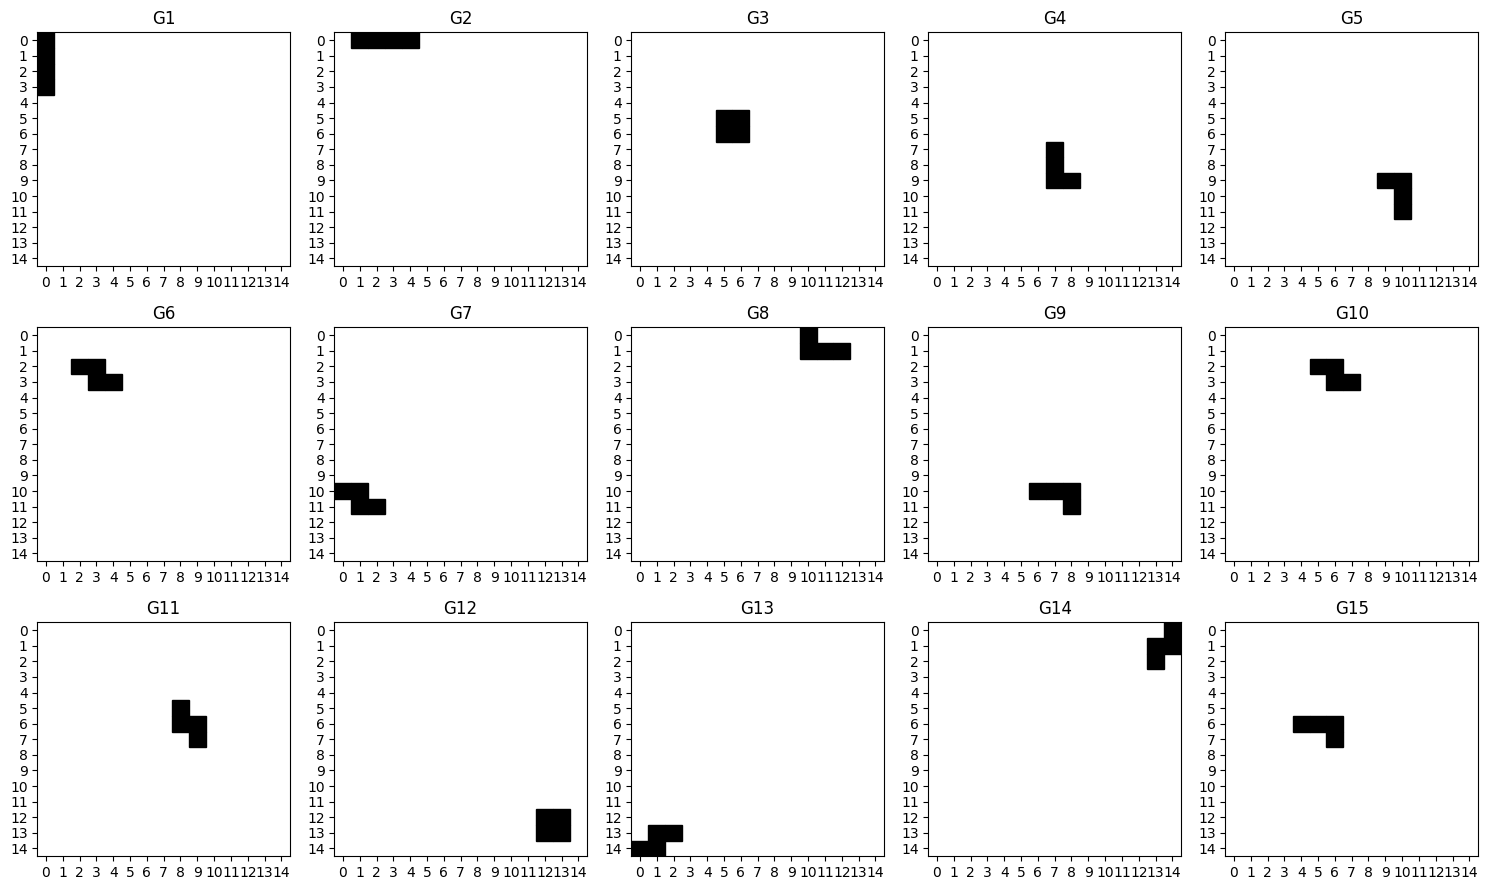

In [43]:
obs_formatted = np.array(list(obs.values()))
is_it_correct = ask(G[goal], obs_formatted)

plot_possible_patterns()

In [ ]:
# obs1
# np.array(obs1.values())
np.array(list_obs1)

# xx = np.array([np.unique(np.array(belief_history)[i], return_counts=True) for i in range(len(belief_history))])

array([[31, 11],
       [15, 33],
       [29,  5],
       [16, 22]])

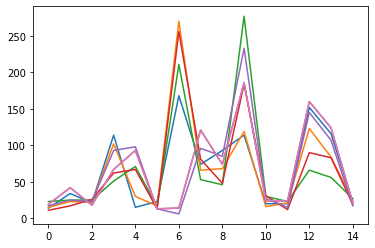

In [ ]:
for i in range(len(belief_history)):
    plt.plot(xx[i,0], xx[i,1])